<a href="https://colab.research.google.com/github/OGBAMI-PRECIOUS/Industrial-ai-fundamentals/blob/main/01_Logistic_Regression_Numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Generate 100 Vibrations reading -N(mean = 5.0, std = 1.5)
vibrations = np.random.normal(5.0, 1.5, 100)

# Generate 100 Temperature reading -N(mean=65.0, std = 10.0)
Temperatures = np.random.normal(65.0, 10.0, 100)

# Stack them to form a feature matrix X of shape (100, 2)
X = np.column_stack((vibrations, Temperatures))

# Create a binary targets (0 or 1) of shape (100, 1)
y = np.random.choice([0, 1], size=(100, 1))

In [3]:
print(X.shape)
print(y.shape)

(100, 2)
(100, 1)


In [4]:
X[:5]

array([[ 5.74507123, 50.84629258],
       [ 4.79260355, 60.79354677],
       [ 5.97153281, 61.57285483],
       [ 7.28454478, 56.97722731],
       [ 4.64876994, 63.38714288]])

In [5]:
# Implementing Z-score Standization
def z_score_norm(X):
  x_mean = np.mean(X, axis=0)
  x_std = np.std(X, axis=0)
  X_norm = (X - x_mean) / x_std
  return X_norm

In [6]:
X_norm = z_score_norm(X)
print(np.mean(X_norm, axis=0))
print(np.std(X_norm, axis=0))

[-1.16823218e-15  1.98507877e-15]
[1. 1.]


In [7]:
# Implementing the sigmoid function
def sigmoid(z):
  return 1 / (1 + np.exp(-z))


In [8]:
w = np.zeros((2, 1))
b = 0
z = np.dot(X_norm, w) + b
f_wb = sigmoid(z)
print(f_wb[:5])

[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]


In [9]:
# Computing the Binary cross entrop (Log Loss) cost function
def compute_cost(X, y, w, b, lambda_=0.1):
  m = X.shape[0]

  # computing predictions f_wb of shape (100, 1)
  f_wb = sigmoid(np.dot(X, w) + b)

  # Compute Unregularized loss function using natural logarithm
  loss = (1/m)*np.sum(-y*np.log(f_wb) - (1 - y) * np.log(1 - f_wb))

  # Compute L2 Regularization cost
  reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)

  # Compute total cost
  total_cost = loss + reg_cost
  return total_cost

In [10]:
compute_cost(X_norm, y, w, b, lambda_=0)

np.float64(0.6931471805599453)

In [11]:
# Computing Gradients
def compute_gradient(X, y, w, b, lambda_=0.1):
  m = X.shape[0]

  # computing predictions f_wb of shape (100, 1)
  f_wb = sigmoid(np.dot(X, w) + b)

  # Computing error
  err = f_wb - y

  # Compute regularized gradient
  dj_dw = (1/m) * np.dot(X.T, err) + (lambda_/m) * w
  dj_db = (1/m) * np.sum(err)

  return dj_dw, dj_db

In [12]:
compute_gradient(X_norm, y, w, b, lambda_=0)

(array([[0.01343117],
        [0.04670826]]),
 np.float64(-0.07))

In [13]:
#  Computing Gradient Descent
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, lambda_):
  J_history = []
  w = w_in
  b = b_in
  for i in range(num_iters):
    dj_dw, dj_db = compute_gradient(X, y, w, b, lambda_)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    cost = compute_cost(X, y, w, b, lambda_)
    J_history.append(cost)
  return w, b, J_history

In [14]:
# Store the outputs
w_final, b_final, J_history = gradient_descent(X_norm, y, w, b, 0.1, 1000, lambda_=0)

# Print the final parameters
print(f"Final Weights (w): {w_final}")
print(f"Final Bias (b): {b_final}")
print(f"Final cost (J): {J_history[-1]}")

Final Weights (w): [[-0.08298597]
 [-0.20296448]]
Final Bias (b): 0.2846845499717616
Final cost (J): 0.6780368156400709


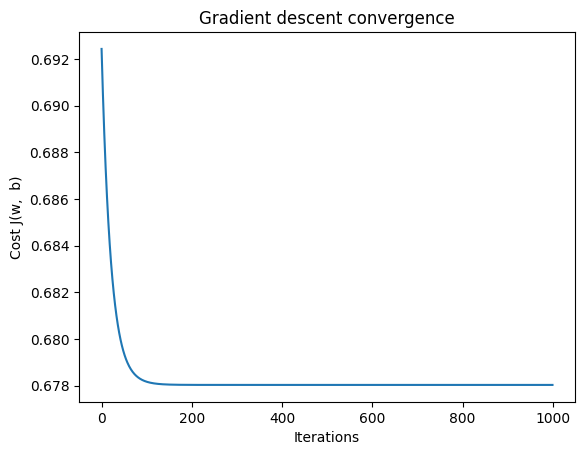

In [15]:
# Plot the cost curve
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost J(w,  b)")
plt.title("Gradient descent convergence")
plt.show()

In [16]:
# Computing Predict function
def predict(X, w, b):
  p = sigmoid(X @ w + b)
  return (p >= 0.5).astype(int)

In [17]:
y_pred = predict(X_norm, w_final, b_final)
print(y_pred[:5])

[[1]
 [1]
 [1]
 [1]
 [1]]


In [18]:
np.mean(y_pred == y) * 100

np.float64(56.00000000000001)

In [20]:
# Physical Rule: stress = 1.5 *vibration_norm + 2.0 * Temp_norm + noise
stress_signal = 1.5 * X_norm[:, 0:1] + 2.0 * X_norm[:, 1:2] + np.random.normal(0, 0.2, size=(100, 1))

# Failure occurs when stress crosses zero threshold
y_physical = (stress_signal >= 0).astype(int)

# Print Class Distribution
print(f"Normal Examples (0): {np.sum(y_physical == 0)}")
print(f"fault Examples (1): {np.sum(y_physical == 1)}")

Normal Examples (0): 50
fault Examples (1): 50


In [21]:
# Retrain Gradient Descent
w_init = np.zeros((2, 1))
b_init = 0
alpha = 0.1
num_iters = 1000
w_final, b_final, J_history = gradient_descent(X_norm, y_physical, w_init, b_init, alpha, num_iters, lambda_=0)

In [22]:
y_pred = predict(X_norm, w_final, b_final)
print(y_pred[:5])
accuracy = np.mean(y_pred == y_physical) * 100
print(f"Final Trained Accuracy: {accuracy:.2f}%")
print(f"Final Cost:{J_history[-1]:.4f}" )

[[0]
 [0]
 [1]
 [1]
 [0]]
Final Trained Accuracy: 98.00%
Final Cost:0.1319


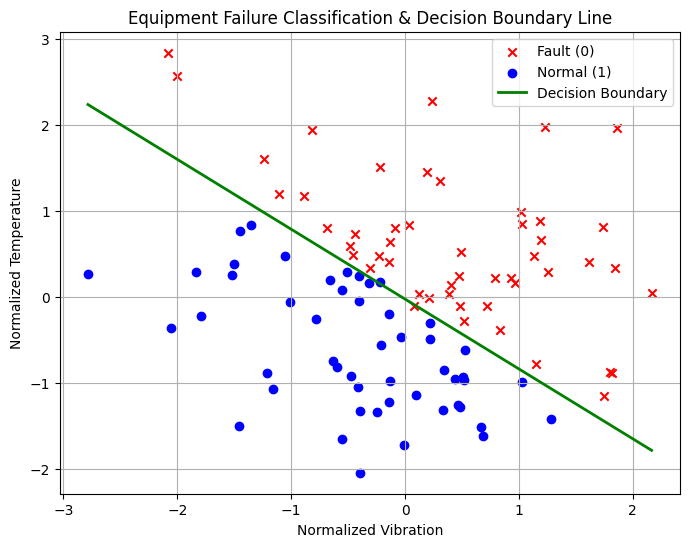

In [23]:
# Plot the Decision Boundary Line

# Seperate Normal and Fault data points
pos = (y_physical == 1).ravel()
neg = (y_physical == 0).ravel()

# Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(X_norm[pos, 0], X_norm[pos, 1], marker='x', color='r', label='Fault (0)')
plt.scatter(X_norm[neg, 0], X_norm[neg, 1], marker='o', color='b', label='Normal (1)')

# Compute Decision Boundary Line Coordinates
x1_vals = np.array([np.min(X_norm[:, 0]), np.max(X_norm[:, 0])])
x2_vals = - (w_final[0] * x1_vals + b_final) / w_final[1]

# Plot Boundary
plt.plot(x1_vals, x2_vals, color="green", linewidth=2, label="Decision Boundary")
plt.xlabel("Normalized Vibration")
plt.ylabel("Normalized Temperature")
plt.title("Equipment Failure Classification & Decision Boundary Line")
plt.legend()
plt.grid(True)
plt.show()


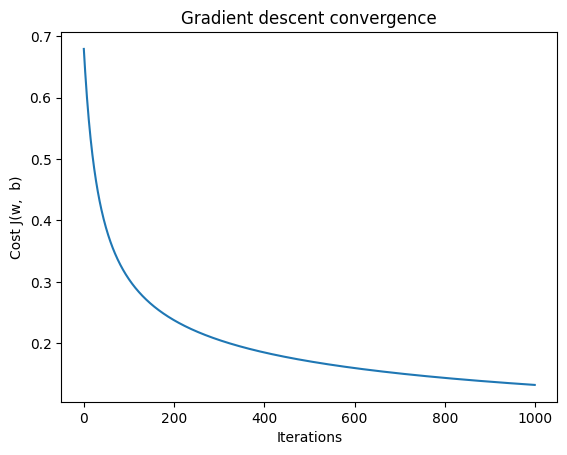

In [24]:
# Plot the cost curve
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost J(w,  b)")
plt.title("Gradient descent convergence")
plt.show()